In [1]:
import pandas as pd

import numpy as np 

from sklearn.metrics import accuracy_score, classification_report, jaccard_score

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Bank_score.csv')

df = data.copy()

print()
print(df['custcat'].value_counts())
print()
print()

df.head()


custcat
2    90
4    77
3    77
1    59
Name: count, dtype: int64




,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


In [3]:
x = df[['tenure', 'age', 'marital', 'retire', 'income', 'ed', 'employ', 'reside']]
y = df['custcat']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 7)

scaler = StandardScaler()
x_train_normalize = scaler.fit_transform(x_train.astype(float))
x_test_normalize = scaler.transform(x_test.astype(float))

print(y_test.value_counts())

custcat
4    20
3    19
1    12
2    10
Name: count, dtype: int64


In [4]:
Accuracy = []
std_accuracy = []

for i in range(1, 21):
    
    k = i
    neigh = KNeighborsClassifier(n_neighbors = k)
    neigh.fit(x_train_normalize, y_train)
    y_pred = neigh.predict(x_test_normalize)
    Accuracy.append(accuracy_score(y_test, y_pred))
    std_accuracy.append(np.std(y_pred == y_test) / np.sqrt(y_pred.shape[0]))# How much my model in different data works good.

count = 1    
for i in Accuracy:
    print("Accuracy: ", i, "-> K:",count)
    count += 1
    
print()

Count = 1
for i in std_accuracy:
    print("std_accuracy: ", i, "-> K:",Count)
    Count += 1

Accuracy:  0.9672131147540983 -> K: 1
Accuracy:  0.9836065573770492 -> K: 2
Accuracy:  0.9836065573770492 -> K: 3
Accuracy:  0.9508196721311475 -> K: 4
Accuracy:  0.9508196721311475 -> K: 5
Accuracy:  0.9508196721311475 -> K: 6
Accuracy:  0.9508196721311475 -> K: 7
Accuracy:  0.9508196721311475 -> K: 8
Accuracy:  0.9508196721311475 -> K: 9
Accuracy:  0.9508196721311475 -> K: 10
Accuracy:  0.9508196721311475 -> K: 11
Accuracy:  0.9508196721311475 -> K: 12
Accuracy:  0.9344262295081968 -> K: 13
Accuracy:  0.9344262295081968 -> K: 14
Accuracy:  0.9344262295081968 -> K: 15
Accuracy:  0.9508196721311475 -> K: 16
Accuracy:  0.9344262295081968 -> K: 17
Accuracy:  0.9508196721311475 -> K: 18
Accuracy:  0.9508196721311475 -> K: 19
Accuracy:  0.9508196721311475 -> K: 20

std_accuracy:  0.022800598712937818 -> K: 1
std_accuracy:  0.01625851487476934 -> K: 2
std_accuracy:  0.01625851487476934 -> K: 3
std_accuracy:  0.027687253153860853 -> K: 4
std_accuracy:  0.027687253153860853 -> K: 5
std_accura

In [5]:
print(np.asanyarray(Accuracy).max())
print()
print(np.asanyarray(std_accuracy).min())

0.9836065573770492

0.01625851487476934


In [6]:
import math 

max_accuracy = np.asanyarray(Accuracy).max()
min_std_accuracy = np.asanyarray(std_accuracy).min()

def find_best_accuracy(Accuracy):
    count = 0
    for i in Accuracy :
        count += 1
        if math.isclose(i, max_accuracy) :
            print(f"In K: {count} There is one of the best accuracy")
            

def find_best_std_accuracy(std_accuracy):
    count = 0
    for i in std_accuracy :
        count += 1
        if math.isclose(i, min_std_accuracy) :
            print(f"In K: {count} There is one of the best std accuracy")

print()
find_best_accuracy(Accuracy)
print()
find_best_std_accuracy(std_accuracy)
print()


In K: 2 There is one of the best accuracy
In K: 3 There is one of the best accuracy

In K: 2 There is one of the best std accuracy
In K: 3 There is one of the best std accuracy



In [7]:
k = 3

neigh = KNeighborsClassifier(n_neighbors = k)

neigh.fit(x_train_normalize, y_train)

y_pred = neigh.predict(x_test_normalize)


Accuracy Score: 0.98


              precision    recall  f1-score   support

           1       1.00      0.92      0.96        12
           2       0.91      1.00      0.95        10
           3       1.00      1.00      1.00        19
           4       1.00      1.00      1.00        20

    accuracy                           0.98        61
   macro avg       0.98      0.98      0.98        61
weighted avg       0.99      0.98      0.98        61




log_loss:  0.6241144086829179

Jaccard_score:  0.9564393939393939



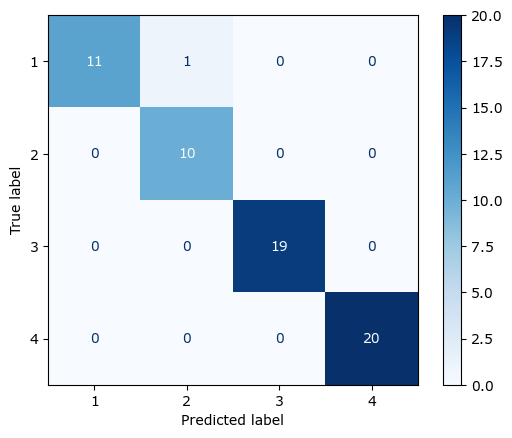

In [8]:
print()
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):1.2f}\n\n\n{classification_report(y_test, y_pred)}")

print()
y_pred_proba = neigh.predict_proba(x_test_normalize)

from sklearn.metrics import log_loss, jaccard_score, ConfusionMatrixDisplay

print()
print()
print("log_loss: ", log_loss(y_test, y_pred_proba))
print()
print("Jaccard_score: ", jaccard_score(y_test, y_pred, average = 'macro'))
print()
ConfusionMatrixDisplay.from_estimator(neigh, x_test_normalize, y_test, display_labels = ['1', '2', '3', '4'], cmap = plt.cm.Blues)